In [1]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

In [2]:
import ibis
import pandas as pd

import src
from src.load import DataLoader

ibis.options.interactive = True
r_colormap_channel = src.r_colormap_name
r_colormap_party = src.r_colormap_party
r_out = str(src.OUT)
pd.options.display.float_format = "{:.1f}".format

In [4]:
%%R -i r_colormap_channel -i r_colormap_party -i r_out

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggh4x)
library(ggeffects)
library(here)
library(ggpubr)

options(scipen = 999)

cmap <- setNames(r_colormap_channel$color, r_colormap_channel$channel)
pmap <- setNames(r_colormap_party$color, r_colormap_party$party)

# Load Data

In [5]:
dl = DataLoader()

videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

sentences = (
    dl.sentences(filtered=True)
    .join(dl.popbert(filtered=False), "sentence_id")
    .to_pandas()
)

sents = sentences.groupby("video_id", observed=True).agg(
    n_sents=("video_id", "size"),
    n_elite=("elite", "sum"),
    n_pplcentr=("pplcentr", "sum"),
    avg_elite=("elite", "mean"),
    avg_pplcentr=("pplcentr", "mean"),
)

# Dataset Summary Table

In [6]:
channel_overview = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("channel", observed=True)
    .agg(
        chFollowers=("channel_follower_count", "first"),
        chName=("channel_uploader_id", "first"),
        nShortVids=("video_is_short", lambda x: (x == 1).sum()),
        nLongVids=("video_is_short", lambda x: (x == 0).sum()),
        nVids=("video_was_live", lambda x: (x == 0).sum()),
        nLikesNA=("video_likes", lambda x: x.isna().sum()),
        meanViews=("video_views", "mean"),
        medianViews=("video_views", "median"),
        meanLikes=("video_likes", "mean"),
        medianLikes=("video_likes", "median"),
        meanVidLen=("video_duration", "mean"),
        nSentences=("n_sents", "sum"),
        first_video=("video_datetime_upload", "min"),
        latest_video=("video_datetime_upload", "max"),
    )
)

In [7]:
inlines = src.OUT / "manuscript/inlines"
inlines.mkdir(exist_ok=True)

In [8]:
# number of broken transcripts

broken_transcripts = dl.broken_transcripts(filtered=True).to_pandas()
n_broken = len(broken_transcripts)

n_broken = f"{n_broken:,.0f}"
p = inlines / "n_broken.txt"
p.unlink(missing_ok=True)
p.write_text(n_broken)
print(f"faulty transcripts: {n_broken}")

faulty transcripts: 142


In [9]:
# sum of durations

sum_of_seconds = videos.video_duration.sum()
hour_duration = f"{round(sum_of_seconds / 60 / 60, 1):,.1f}"
p = inlines / "sum_duration.txt"
p.unlink(missing_ok=True)
p.write_text(hour_duration)
print(f"Total sum of video durations: {hour_duration} hours")

Total sum of video durations: 2,337.0 hours


In [10]:
# number of videos

count_videos = len(videos)
count_videos = f"{count_videos:,.0f}"
p = inlines / "n_videos.txt"
p.unlink(missing_ok=True)
p.write_text(count_videos)
print(f"Total number of valid videos: {count_videos}")

Total number of valid videos: 19,060


In [11]:
# number of sentencs

count_sents = len(sentences)
count_sents = f"{count_sents:,.0f}"
p = inlines / "n_sents.txt"
p.unlink(missing_ok=True)
p.write_text(count_sents)
print(f"Total number of valid sentences: {count_sents}")

Total number of valid sentences: 1,281,590


In [12]:
summary_table = channel_overview.drop(["first_video", "latest_video"], axis=1)

summary_table

,chFollowers,chName,nShortVids,nLongVids,nVids,nLikesNA,meanViews,medianViews,meanLikes,medianLikes,meanVidLen,nSentences
channel,,,,,,,,,,,,
AfD BT,539000,@AfDFraktionimBundestag,648,5562,6210,0,54144.4,16631.0,4401.5,2060.0,412.4,378258
AfD DE,340000,@AfDTV,604,1245,1849,108,53807.9,19720.0,4376.2,2555.0,555.0,173264
CDU DE,30800,@cdutv,533,322,855,1,20565.5,1366.0,200.2,29.0,552.6,74302
CDU/CSU BT,8050,@cducsu,420,281,701,599,2083.4,254.0,140.4,25.0,624.7,60613
CSU BT,4930,@csuimbundestag9622,14,394,408,408,6222.3,319.5,NaN,NaN,350.4,20451
CSU DE,6890,@csumedia,113,69,182,4,25333.2,987.5,44.8,25.5,415.2,13745
FDP BT,24500,@fdpbt,288,346,634,1,22455.2,1675.5,291.3,59.0,385.3,39182
FDP DE,29600,@FDP,392,325,717,716,23456.1,1233.0,104.0,104.0,555.9,57304
Greens BT,3000,@gruenebundestag,127,93,220,0,4124.2,943.0,56.3,17.0,350.7,11520


In [13]:
path = src.OUT / "tables/videos_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "nShortVids",
        "nLongVids",
        "nVids",
        "meanVidLen",
    ]
].to_csv(path)

In [14]:
path = src.OUT / "tables/channel_descriptives.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "chName",
        "chFollowers",
    ]
].to_csv(path)

In [15]:
path = src.OUT / "tables/video_descriptives_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    ["meanViews", "medianViews", "meanLikes", "medianLikes", "nSentences"]
].fillna(
    "NA",
).to_csv(path)

# View Count Violin Plot

In [16]:
df = videos.merge(sents, on="video_id")

In [17]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      likes = video_likes + 1,
      views = video_views + 1,
) |>
pivot_longer(
   c(likes, views),
   names_to = "var",
   values_to = "val"
)

plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans="log10", breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      axis.ticks.x=element_blank(),
      axis.title.x=element_blank(),
      legend.position = "none"
   ) +
   facet_wrap(~var, ncol=1, scales="free_y") +
   ylab("log(10)")

options(warn = -1)
p <- here(r_out, "/figures/view_count.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=12.4)
plot
options(warn = 0)

# Populism Amount Plot

In [18]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      elite = (n_elite / n_sents * 100) + 1,
      pplcentr = (n_pplcentr / n_sents * 100) + 1,
) |>
pivot_longer(
   c(elite, pplcentr),
   names_to = "var",
   values_to = "val"
)


plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   facet_wrap(~var, ncol=1, scales="free_y")

options(warn = -1)
p <- here(r_out, "/figures/populism_per_party.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=12.4)
plot
options(warn = 0)

# Populism Over Time

In [19]:
df

,channel_uploader_id,channel_follower_count,channel_collected,channel_description,channel,channel_id,party,video_id,video_title,video_duration,video_views,video_likes,video_was_live,video_datetime_upload,video_is_short,n_sents,n_elite,n_pplcentr,avg_elite,avg_pplcentr
0,@AfDFraktionimBundestag,539000,2025-04-28 16:29:00,Offizieller Kanal der AfD-Fraktion im Deutsche...,AfD BT,UC_dZp8bZipnjntBGLVHm6rw,AfD,SmJytYj14lY,"Halbe CDU fehlt, weil sie auf dem Weg ins Gefä...",281,273588,19822.0,False,2021-03-26 12:15:03,False,57,7,1,0.1,0.0
1,@AfDFraktionimBundestag,539000,2025-04-28 16:29:00,Offizieller Kanal der AfD-Fraktion im Deutsche...,AfD BT,UC_dZp8bZipnjntBGLVHm6rw,AfD,FyGb8nk7qhA,"Dr. Rainer Kraft: Hören sie auf, unsere Natur ...",359,3400,505.0,False,2018-10-10 17:30:37,False,59,11,0,0.2,0.0
2,@AfDFraktionimBundestag,539000,2025-04-28 16:29:00,Offizieller Kanal der AfD-Fraktion im Deutsche...,AfD BT,UC_dZp8bZipnjntBGLVHm6rw,AfD,PgGobB2--28,Mit dem Wohnungsmarkt spielt man nicht! - AfD-...,343,5090,693.0,False,2021-02-27 09:00:05,False,45,3,1,0.1,0.0
3,@AfDFraktionimBundestag,539000,2025-04-28 16:29:00,Offizieller Kanal der AfD-Fraktion im Deutsche...,AfD BT,UC_dZp8bZipnjntBGLVHm6rw,AfD,8MrH4DWkbMc,GroKo bei der Sicherheitspolitik weder willens...,242,6634,1208.0,False,2020-11-22 17:00:04,False,37,10,2,0.3,0.1
4,@AfDFraktionimBundestag,539000,2025-04-28 16:29:00,Offizieller Kanal der AfD-Fraktion im Deutsche...,AfD BT,UC_dZp8bZipnjntBGLVHm6rw,AfD,PnRqX7y81dg,"Wollen Sie Tampons über Teheran abwerfen, Frau...",320,212170,17899.0,False,2022-02-17 14:22:35,False,46,11,4,0.2,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19055,@spdbt,4450,2025-04-29 16:22:23,Viel erreicht – noch viel vor! 🚀 Hier gibt's s...,SPD BT,UCUVSxH8r5fj3Uki5uAcyQaw,SPD,VzzWKLY8V7o,Gesundheit geht gerechter!,60,642,NaN,False,2024-10-14 13:57:16,True,7,0,2,0.0,0.3
19056,@spdbt,4450,2025-04-29 16:22:23,Viel erreicht – noch viel vor! 🚀 Hier gibt's s...,SPD BT,UCUVSxH8r5fj3Uki5uAcyQaw,SPD,U2MLjbfEnPc,"The One And Only Karl Lauterbach erklärt, wies...",46,249,17.0,False,2024-05-20 21:10:59,True,5,0,0,0.0,0.0
19057,@spdbt,4450,2025-04-29 16:22:23,Viel erreicht – noch viel vor! 🚀 Hier gibt's s...,SPD BT,UCUVSxH8r5fj3Uki5uAcyQaw,SPD,d6Kpyo1JPI4,"Was würde eigentlich passieren, wenn die AfD d...",58,3533,46.0,False,2024-02-14 09:55:21,True,9,2,0,0.2,0.0
19058,@spdbt,4450,2025-04-29 16:22:23,Viel erreicht – noch viel vor! 🚀 Hier gibt's s...,SPD BT,UCUVSxH8r5fj3Uki5uAcyQaw,SPD,7gwcMvDreTQ,DigitalPakt Schule - Schulcampus Röbel rüstet...,453,1765,40.0,False,2020-11-11 11:10:24,False,65,0,0,0.0,0.0


In [39]:
%%R
cmap

     AfD BT      AfD DE  CDU/CSU BT      CDU DE      CSU BT      CSU DE 
  "#0489DB"   "#0489DB"   "#000000"   "#000000"   "#000000"   "#000000" 
  Greens DE   Greens BT     Left DE Left BT old Left BT new      FDP DE 
  "#1AA037"   "#1AA037"   "#8B008B"   "#8B008B"   "#8B008B"   "#FFEF00" 
     FDP BT      SPD DE      SPD BT 
  "#FFEF00"   "#E3000F"   "#E3000F" 


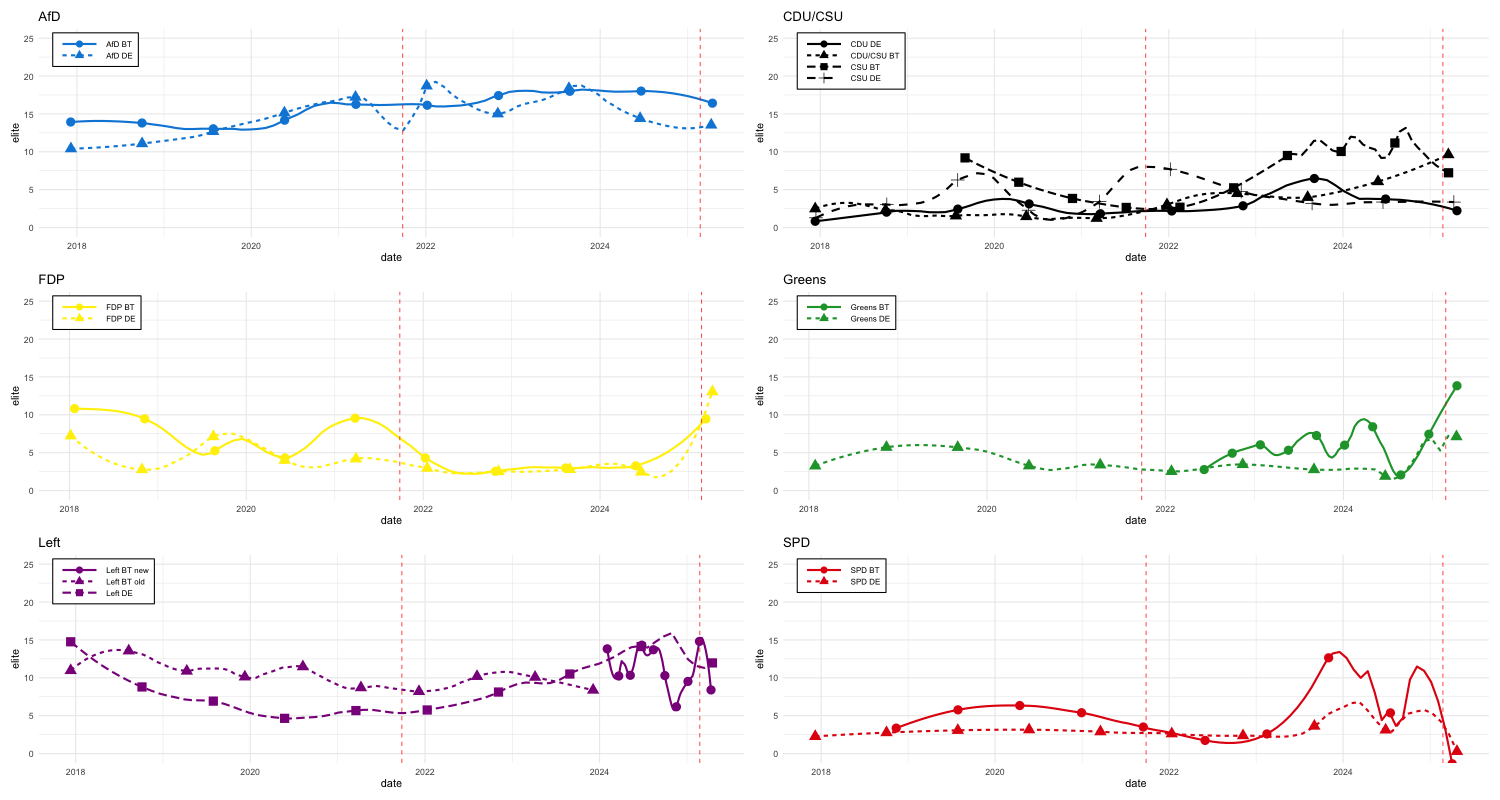

In [52]:
%%R -i df -w 1500 -h 800

df_plot <- df |>
   mutate(
      elite = (n_elite / n_sents * 100) + 1,
      pplcentr = (n_pplcentr / n_sents * 100) + 1,
      date = as.Date(video_datetime_upload)
) |>
group_by(party, channel, date) |>
summarize(
    elite = mean(elite, na.rm = T),
    pplcentr = mean(pplcentr, na.rm = T),
    .groups = "drop"
)

election_dates <- as.Date(c("2021-09-26", "2025-02-23"))
parties <- unique(df_plot$party)
plots <- list()

y_min <- 0
y_max <- 25

# Add this after geom_smooth():
stat_smooth_func <- function(mapping = NULL, data = NULL, geom = "point",
                           position = "identity", ..., method = "loess", 
                           se = FALSE, n = 20, span = 0.3) {
  layer(data = data, mapping = mapping, stat = StatSmooth, geom = geom, 
        position = position, show.legend = NA, inherit.aes = TRUE,
        params = list(method = method, se = se, n = n, span = span, ...))
}

for(p in parties) {
  party_data <- df_plot %>% filter(party == p)
  
  plots[[p]] <- ggplot(party_data, aes(linetype = channel, x = date, y = elite)) +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, span = 0.3, color = pmap[[p]]) +
    stat_smooth_func(aes(shape = channel), method = "loess", span = 0.3, 
                 color = pmap[[p]], size = 4, n = 10, formula = y ~ x) +
    geom_vline(xintercept = election_dates, color = "red", linetype = "dashed", alpha = 0.7) +
    coord_cartesian(ylim = c(y_min, y_max)) +
    labs(title = p) +
    theme_minimal() +
    theme(
      legend.position = c(0.02, 0.98),  # Top-left corner
      legend.justification = c(0, 1),
      legend.background = element_rect(fill = "white"),
      legend.title = element_blank(),
      legend.text = element_text(size = 8),
      legend.key.size = unit(0.4, "cm"),
      legend.key.width = unit(1.5, "cm")
    ) +
    guides(
        shape = guide_legend(override.aes = list(size = 3)),
    )
}

# Combine plots
library(patchwork)
combined_plot <- wrap_plots(plots, ncol = 2)
combined_plot